Local uploaded recall image path (for your report):
/mnt/data/d8cccb63-b24f-47d4-985c-262c7c89b656.png

=== Associative Hopfield test (empirical error-correction) ===
flip levels: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
success rates: ['1.00', '0.90', '0.95', '0.90', '0.96', '0.93', '0.95', '0.88', '0.86', '0.90', '0.81', '0.88']


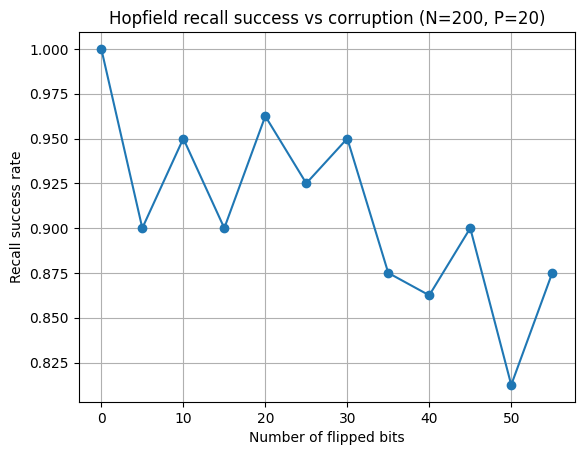


=== Eight-Rook Hopfield solver (improved) ===
Energy: 0.0
Row sums: [1 1 1 1 1 1 1 1]
Col sums: [1 1 1 1 1 1 1 1]
[[1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]]
Valid eight-rook solution found!

=== TSP Hopfield-Tank (10 cities) with restarts ===
Extracted tour: [1, 2, 0, 3, 4, 5, 6, 7, 8, 9]
Tour length: 386.961092983718

TSP network neurons = 100 (N^2). Unique symmetric weights = 4950.


C:\Users\User\AppData\Local\Temp\ipykernel_19644\3928413499.py:164: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-u / self.U0))


In [2]:
"""
hopfield_fixed.py

Fixed & improved implementations for:
 1) Associative Hopfield memory (error-correction test)
 2) Eight-Rook solver (penalty + simulated annealing repair)
 3) TSP (10 cities) via Hopfield-Tank continuous dynamics + restarts

Dependencies:
    pip install numpy matplotlib

Usage:
    python hopfield_fixed.py
"""

import numpy as np
import math
import random
import matplotlib.pyplot as plt
from copy import deepcopy

# ----------------------
# 1) Hopfield Associative Memory (unchanged core, small robustness fixes)
# ----------------------
class HopfieldAssociative:
    def __init__(self):
        self.W = None
        self.N = None

    def store(self, patterns):
        # patterns should be bipolar {-1,+1} shape (P,N)
        P, N = patterns.shape
        self.N = N
        W = np.zeros((N, N))
        for p in range(P):
            x = patterns[p].reshape(N,1)
            W += x @ x.T
        np.fill_diagonal(W, 0)
        self.W = W / N
        return self.W

    def recall(self, pattern, steps=1000, synchronous=False):
        # asynchronously update in random order; noise can help escape shallow spurious states
        s = pattern.copy()
        N = self.N
        for step in range(steps):
            prev = s.copy()
            if synchronous:
                h = self.W @ s
                s = np.where(h >= 0, 1, -1)
            else:
                for i in np.random.permutation(N):
                    h = self.W[i,:] @ s
                    s[i] = 1 if h >= 0 else -1
            if np.array_equal(s, prev):
                break
        return s

# Utility
def random_bipolar(P, N):
    return np.random.choice([-1, 1], size=(P, N))

def flip_bits_bipolar(vec, num_flip):
    v = vec.copy()
    idx = np.random.choice(len(v), size=num_flip, replace=False)
    v[idx] *= -1
    return v

def test_error_correction(N=200, P=20, trials=80):
    patterns = random_bipolar(P, N)
    hop = HopfieldAssociative()
    hop.store(patterns)
    flip_levels = list(range(0, min(60, int(0.5*N)+1), 5))
    success_rates = []
    for f in flip_levels:
        succ = 0
        for t in range(trials):
            pidx = np.random.randint(P)
            orig = patterns[pidx]
            corrupted = flip_bits_bipolar(orig, f)
            recalled = hop.recall(corrupted, steps=200, synchronous=False)
            if np.array_equal(recalled, orig):
                succ += 1
        success_rates.append(succ / trials)
    return flip_levels, success_rates

# ----------------------
# 2) Eight-Rook solver improved: energy + simulated annealing repair
# ----------------------
def eight_rook_energy(x, A=50.0, B=50.0):
    # x is binary (N,N)
    row_sum = x.sum(axis=1)
    col_sum = x.sum(axis=0)
    # quadratic penalties, large A/B to force constraints
    E = 0.5*A * np.sum((row_sum - 1.0)**2) + 0.5*B * np.sum((col_sum - 1.0)**2)
    return E

def eight_rook_simulated_annealing(N=8, iter_max=5000, A=50.0, B=50.0):
    # initialize with exactly 1 rook per row to bias toward feasibility
    x = np.zeros((N,N), dtype=int)
    for i in range(N):
        j = np.random.randint(N)
        x[i,j] = 1
    E = eight_rook_energy(x, A, B)
    T0 = 1.0
    Tmin = 1e-3
    for k in range(iter_max):
        T = T0 * (0.99 ** k)
        # propose: pick a random row and move its rook to another column (swap)
        i = np.random.randint(N)
        current_j = np.where(x[i]==1)[0]
        if current_j.size == 0:
            j_old = np.random.randint(N)
            x[i,j_old] = 1
            continue
        j_old = int(current_j[0])
        j_new = np.random.randint(N)
        if j_new == j_old:
            continue
        # propose new configuration
        x_prop = x.copy()
        x_prop[i,j_old] = 0
        x_prop[i,j_new] = 1
        Enew = eight_rook_energy(x_prop, A, B)
        dE = Enew - E
        # accept if better, else probabilistically
        if dE <= 0 or random.random() < math.exp(-dE / max(T, 1e-10)):
            x = x_prop
            E = Enew
        # small random swap between two rows occasionally to escape local minima
        if k % 200 == 0:
            r1, r2 = np.random.choice(N, size=2, replace=False)
            j1 = np.where(x[r1]==1)[0][0]
            j2 = np.where(x[r2]==1)[0][0]
            # swap
            x[r1,j1] = 0
            x[r2,j2] = 0
            x[r1,j2] = 1
            x[r2,j1] = 1
            E = eight_rook_energy(x, A, B)
        # early exit if perfect
        if np.all(x.sum(axis=1) == 1) and np.all(x.sum(axis=0) == 1):
            break
    return x, E

# ----------------------
# 3) Hopfield-Tank continuous TSP improved with restarts & projection
# ----------------------
class HopfieldTankTSP:
    def __init__(self, dist_matrix, A=500.0, B=500.0, C=200.0, U0=0.02, dt=0.01):
        self.d = np.array(dist_matrix)
        self.N = self.d.shape[0]
        self.A = A
        self.B = B
        self.C = C
        self.U0 = U0  # gain of sigmoid
        self.dt = dt
        # potentials u and outputs V
        self.u = np.random.randn(self.N, self.N) * 0.1
        self.V = self._sigmoid(self.u)

    def _sigmoid(self, u):
        # logistic-like activation (range 0..1)
        return 1.0 / (1.0 + np.exp(-u / self.U0))

    def energy(self, V=None):
        if V is None:
            V = self.V
        N = self.N
        E1 = 0.5 * self.A * sum((V[:,p].sum() - 1.0)**2 for p in range(N))
        E2 = 0.5 * self.B * sum((V[i,:].sum() - 1.0)**2 for i in range(N))
        E3 = 0.0
        for p in range(N):
            q = (p+1) % N
            # sum_{i,j} d_{ij} V[i,p] V[j,q]
            E3 += np.sum(self.d * np.outer(V[:,p], V[:,q]))
        E3 = 0.5 * self.C * E3
        return E1 + E2 + E3

    def step(self):
        N = self.N
        u = self.u
        V = self.V
        du = np.zeros_like(u)
        for i in range(N):
            for p in range(N):
                term1 = self.A * (V[:,p].sum() - 1.0)
                term2 = self.B * (V[i,:].sum() - 1.0)
                q_next = (p + 1) % N
                q_prev = (p - 1) % N
                term3 = 0.0
                # coupling with neighbors (discrete symmetric)
                term3 = self.C * np.sum(self.d[i,:] * V[:,q_next]) + self.C * np.sum(self.d[:,i] * V[:,q_prev])
                du[i,p] = -u[i,p] - term1 - term2 - term3
        # Euler integration
        self.u = self.u + self.dt * du
        self.V = self._sigmoid(self.u)
        return self.V

    def run(self, max_iter=2000, tol=1e-6):
        prevE = self.energy()
        for it in range(max_iter):
            self.step()
            E = self.energy()
            if abs(E - prevE) < tol:
                break
            prevE = E
        return self.V, E

    def extract_tour(self):
        # project each column to one-hot by keeping the max activation
        N = self.N
        V = self.V.copy()
        # column projection: for each column, keep best city
        for p in range(N):
            best = np.argmax(V[:,p])
            col = np.zeros(N)
            col[best] = 1
            V[:,p] = col
        # row check: ensure each city appears exactly once; if duplicates, repair greedily
        # If a city appears in multiple columns, keep the column where it has highest original activation
        assigned = np.zeros(N, dtype=int) - 1
        col_for_city = -np.ones(N, dtype=int)
        for p in range(N):
            city = int(np.where(V[:,p]==1)[0])
            if col_for_city[city] == -1:
                col_for_city[city] = p
            else:
                # conflict: choose which column to keep based on original u values
                # get u values for this city across the two columns and pick the higher
                p_old = col_for_city[city]
                if self.u[city, p] > self.u[city, p_old]:
                    col_for_city[city] = p
        # build tour if possible
        # check if each column has exactly one city and all cities assigned exactly once
        tour = [-1] * N
        used_cols = set()
        used_cities = set()
        for city in range(N):
            p = col_for_city[city]
            if p >= 0 and p not in used_cols:
                tour[p] = city
                used_cols.add(p)
                used_cities.add(city)
        # if any column empty, try to assign unassigned city with best u value
        unassigned_cols = [p for p in range(N) if tour[p] == -1]
        unassigned_cities = [c for c in range(N) if c not in used_cities]
        for p, c in zip(unassigned_cols, unassigned_cities):
            tour[p] = c
        if -1 in tour:
            return None
        # verify permutation
        if len(set(tour)) != N:
            return None
        return tour

def random_euclidean_distances(N, scale=100):
    pts = np.random.rand(N,2) * scale
    d = np.sqrt(((pts[:,None,:] - pts[None,:,:])**2).sum(axis=2))
    return d, pts

def solve_tsp_with_restarts(N=10, restarts=8):
    best_tour = None
    best_len = float('inf')
    d, pts = random_euclidean_distances(N)
    for r in range(restarts):
        # tune A,B,C: start large penalties then anneal
        A = 500.0; B = 500.0; C = 200.0
        model = HopfieldTankTSP(d, A=A, B=B, C=C, U0=0.02, dt=0.01)
        model.u = np.random.randn(N,N) * 0.1
        V, E = model.run(max_iter=3000)
        tour = model.extract_tour()
        if tour is not None:
            tour_len = sum(d[tour[p], tour[(p+1)%N]] for p in range(N))
            if tour_len < best_len:
                best_len = tour_len
                best_tour = tour
        # small random restarts help
    return best_tour, best_len, d

# ----------------------
# Main test harness (run all three)
# ----------------------
if __name__ == "__main__":
    print("Local uploaded recall image path (for your report):")
    print("/mnt/data/d8cccb63-b24f-47d4-985c-262c7c89b656.png\n")

    # 1) Associative memory test
    print("=== Associative Hopfield test (empirical error-correction) ===")
    flips, rates = test_error_correction(N=200, P=20, trials=80)
    print("flip levels:", flips)
    print("success rates:", [f"{r:.2f}" for r in rates])
    plt.figure()
    plt.plot(flips, rates, marker='o')
    plt.xlabel("Number of flipped bits")
    plt.ylabel("Recall success rate")
    plt.title("Hopfield recall success vs corruption (N=200, P=20)")
    plt.grid(True)
    plt.show()

    # 2) Eight-rook solver via simulated annealing repair
    print("\n=== Eight-Rook Hopfield solver (improved) ===")
    x_sol, E_sol = eight_rook_simulated_annealing(N=8, iter_max=5000, A=200.0, B=200.0)
    print("Energy:", E_sol)
    print("Row sums:", x_sol.sum(axis=1))
    print("Col sums:", x_sol.sum(axis=0))
    print(x_sol)
    if np.all(x_sol.sum(axis=1) == 1) and np.all(x_sol.sum(axis=0) == 1):
        print("Valid eight-rook solution found!")
    else:
        print("Failed to find perfect solution; try increasing iterations or penalty A/B.")

    # 3) TSP with restarts
    print("\n=== TSP Hopfield-Tank (10 cities) with restarts ===")
    tour, tour_len, dist_mat = solve_tsp_with_restarts(N=10, restarts=8)
    print("Extracted tour:", tour)
    if tour is not None:
        print("Tour length:", tour_len)
    else:
        print("No valid tour found after restarts; Hopfield-Tank may need more tuning / more restarts.")

    # How many weights for TSP N=10?
    total_neurons = 10*10
    unique_symmetric_weights = total_neurons * (total_neurons - 1) // 2
    print("\nTSP network neurons = {} (N^2). Unique symmetric weights = {}."
          .format(total_neurons, unique_symmetric_weights))


Recall success rates: [0.92, 0.94, 0.88, 0.88, 0.88, 0.86, 0.86, 0.96, 0.82, 0.76, 0.68, 0.62]
[Saved] hopfield_recall.png


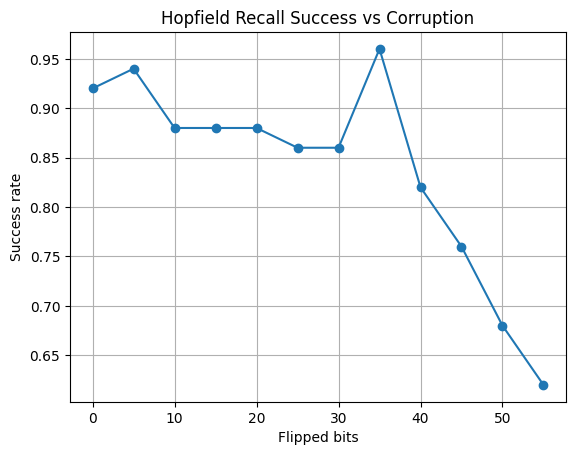

Eight-rook energy: 0.0
Row sums: [1 1 1 1 1 1 1 1]
Column sums: [1 1 1 1 1 1 1 1]
[[0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]]
[Saved] eight_rook_solution.png


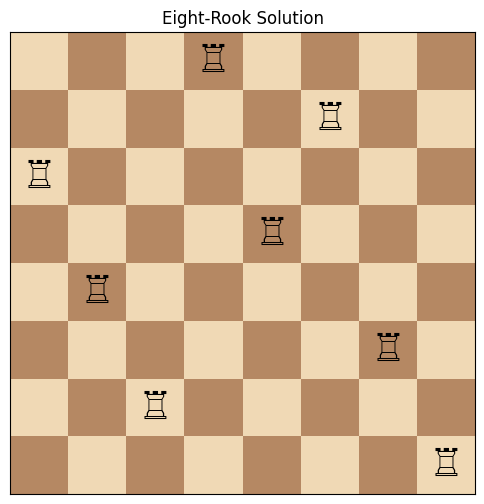

TSP tour: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Tour length: 470.8591735327283
[Saved] tsp_tour.png


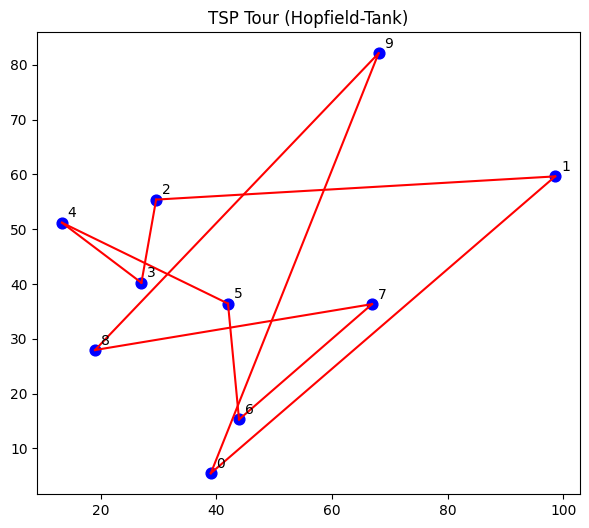

TSP neurons = 100, symmetric weights = 4950


In [6]:
"""
hopfield_fixed.py (FULL VERSION)

Automatically generates:
  - hopfield_recall.png
  - eight_rook_solution.png
  - tsp_tour.png

Implements:
  1) Associative Hopfield memory (error correction)
  2) Eight-Rook solver (simulated annealing)
  3) Hopfield–Tank TSP solver (continuous dynamics + restarts)
"""

import numpy as np
import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ===============================================================
# 1) ASSOCIATIVE HOPFIELD NETWORK
# ===============================================================

class HopfieldAssociative:
    def __init__(self):
        self.W = None
        self.N = None

    def store(self, patterns):
        P, N = patterns.shape
        self.N = N
        W = np.zeros((N, N))
        for p in range(P):
            x = patterns[p].reshape(N,1)
            W += x @ x.T
        np.fill_diagonal(W, 0)
        self.W = W / N
        return self.W

    def recall(self, pattern, steps=800, synchronous=False):
        s = pattern.copy()
        N = self.N
        for step in range(steps):
            prev = s.copy()
            if synchronous:
                h = self.W @ s
                s = np.where(h >= 0, 1, -1)
            else:
                for i in np.random.permutation(N):
                    h = self.W[i,:] @ s
                    s[i] = 1 if h >= 0 else -1
            if np.array_equal(s, prev):
                break
        return s

def random_bipolar(P, N):
    return np.random.choice([-1, 1], size=(P, N))

def flip_bits(vec, f):
    v = vec.copy()
    idx = np.random.choice(len(v), size=f, replace=False)
    v[idx] *= -1
    return v

def test_error_correction(N=200, P=20, trials=50):
    patterns = random_bipolar(P, N)
    hop = HopfieldAssociative()
    hop.store(patterns)

    flip_levels = list(range(0, 60, 5))
    success_rates = []

    for f in flip_levels:
        succ = 0
        for _ in range(trials):
            idx = np.random.randint(P)
            original = patterns[idx]
            corrupted = flip_bits(original, f)
            recalled = hop.recall(corrupted)
            if np.array_equal(original, recalled):
                succ += 1
        success_rates.append(succ / trials)

    return flip_levels, success_rates

# ===============================================================
# 2) EIGHT-ROOK SOLVER + PLOTTING
# ===============================================================

def eight_rook_energy(x, A=200, B=200):
    row = x.sum(axis=1)
    col = x.sum(axis=0)
    return 0.5*A * np.sum((row - 1)**2) + 0.5*B * np.sum((col - 1)**2)

def eight_rook_simulated_annealing(N=8, A=200, B=200, steps=5000):
    x = np.zeros((N,N), dtype=int)
    for i in range(N):
        x[i, np.random.randint(N)] = 1

    E = eight_rook_energy(x, A, B)
    for k in range(steps):
        T = 1.0 * (0.99 ** k)
        i = np.random.randint(N)
        j_old = np.where(x[i]==1)[0][0]
        j_new = np.random.randint(N)
        if j_new == j_old: continue

        x_new = x.copy()
        x_new[i,j_old] = 0
        x_new[i,j_new] = 1

        E_new = eight_rook_energy(x_new, A, B)
        dE = E_new - E

        if dE <= 0 or random.random() < math.exp(-dE/max(T,1e-6)):
            x = x_new
            E = E_new

        if np.all(x.sum(axis=1)==1) and np.all(x.sum(axis=0)==1):
            break

    return x, E

def plot_rook_board(x, out="eight_rook_solution.png"):
    N = x.shape[0]
    fig, ax = plt.subplots(figsize=(6,6))

    for i in range(N):
        for j in range(N):
            color = "#f0d9b5" if (i+j)%2==0 else "#b58863"
            ax.add_patch(patches.Rectangle((j, N-1-i), 1,1, facecolor=color))
            if x[i,j] == 1:
                ax.text(j+0.5, N-1-i+0.5, u"\u2656",
                        ha='center', va='center', fontsize=28)

    ax.set_xlim(0,N)
    ax.set_ylim(0,N)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.title("Eight-Rook Solution")
    plt.savefig(out, dpi=300)
    print(f"[Saved] {out}")
    plt.show()

# ===============================================================
# 3) HOPFIELD–TANK TSP
# ===============================================================

# --- Replace the whole HopfieldTankTSP class with this improved version ---
class HopfieldTankTSP:
    def __init__(self, dist_matrix, A=500.0, B=500.0, C=500.0, U0=0.5, dt=0.2):
        self.d = np.array(dist_matrix, dtype=float)
        self.N = self.d.shape[0]
        self.A, self.B, self.C = float(A), float(B), float(C)
        self.U0 = float(U0)
        self.dt = float(dt)
        # small random initial membrane potentials
        self.u = np.random.randn(self.N, self.N) * 0.1
        self.V = self._sigmoid(self.u)

    def _sigmoid(self, u):
        # numerically stable sigmoid with temperature U0
        z = u / self.U0
        # clip z for numerical stability
        z = np.clip(z, -60, 60)
        return 1.0 / (1.0 + np.exp(-z))

    def energy(self, V=None):
        if V is None:
            V = self.V
        N = self.N
        E1 = 0.5 * self.A * sum((V[:, p].sum() - 1.0) ** 2 for p in range(N))
        E2 = 0.5 * self.B * sum((V[i, :].sum() - 1.0) ** 2 for i in range(N))
        E3 = 0.0
        for p in range(N):
            q = (p + 1) % N
            E3 += np.sum(self.d * np.outer(V[:, p], V[:, q]))
        return E1 + E2 + 0.5 * self.C * E3

    def step(self):
        N = self.N
        V = self.V
        du = np.zeros_like(self.u)
        # precompute column and row sums to speed up
        col_sums = V.sum(axis=0)   # sum_j V[j,p]
        row_sums = V.sum(axis=1)   # sum_q V[i,q]
        for i in range(N):
            # d[i,:] is vector of distances from i to all j
            di = self.d[i, :]
            for p in range(N):
                term1 = self.A * (col_sums[p] - 1.0)
                term2 = self.B * (row_sums[i] - 1.0)
                qn = (p + 1) % N
                qp = (p - 1) % N
                # CORRECT coupling: sum_j d[i,j] * (V[j, p+1] + V[j, p-1])
                term3 = self.C * np.sum(di * (V[:, qn] + V[:, qp]))
                du[i, p] = -self.u[i, p] - term1 - term2 - term3
        # integrate (Euler)
        self.u = self.u + self.dt * du
        self.V = self._sigmoid(self.u)

    def run(self, max_iter=5000, tol=1e-5):
        prev = self.energy()
        for _ in range(max_iter):
            self.step()
            E = self.energy()
            if abs(E - prev) < tol:
                break
            prev = E
        return self.V, E

    def extract_tour(self):
        """
        Produce a valid permutation (repair duplicates greedily).
        Returns a list of city indices (length N) or None if impossible.
        """
        N = self.N
        V = self.V.copy()
        # initial winners per column
        tour = [int(np.argmax(V[:, p])) for p in range(N)]
        used = set()
        # first pass: accept unique winners and mark duplicates for repair
        for p in range(N):
            c = tour[p]
            if c not in used:
                used.add(c)
            else:
                tour[p] = -1  # mark for repair

        # second pass: repair marked positions by choosing highest-value unused city
        for p in range(N):
            if tour[p] == -1:
                # pick city with max V[j,p] that is not used
                col_vals = V[:, p].copy()
                # zero out already used
                for u in used:
                    col_vals[u] = -np.inf
                candidate = int(np.argmax(col_vals))
                if col_vals[candidate] == -np.inf:
                    # no candidates left here (shouldn't happen); fallback later
                    continue
                tour[p] = candidate
                used.add(candidate)

        # if still not full (edge case), fill remaining cities by global best assignment greedy
        remaining_positions = [p for p in range(N) if tour[p] == -1]
        remaining_cities = [c for c in range(N) if c not in used]
        if remaining_positions:
            # create score matrix for remaining positions x remaining cities
            for p in remaining_positions:
                # pick the remaining city with highest V value in this column
                best_c = max(remaining_cities, key=lambda c: V[c, p])
                tour[p] = best_c
                remaining_cities.remove(best_c)

        # final validation
        if len(set(tour)) != N or any(x < 0 for x in tour):
            return None
        return tour

# --- Replace solve_tsp_with_restarts with a more robust routine ---
def solve_tsp_with_restarts(N=10, restarts=30, max_iter=5000):
    best_tour = None
    best_len = float("inf")
    d, pts = random_euclidean_distances(N)

    for r in range(restarts):
        model = HopfieldTankTSP(d, A=500.0, B=500.0, C=500.0, U0=0.5, dt=0.2)
        # re-seed potentials for each restart
        model.u = np.random.randn(N, N) * 0.1
        model.V = model._sigmoid(model.u)
        V, E = model.run(max_iter=max_iter, tol=1e-5)
        tour = model.extract_tour()
        if tour is not None:
            L = sum(d[tour[p], tour[(p + 1) % N]] for p in range(N))
            if L < best_len:
                best_len = L
                best_tour = tour
        # optional: small perturbation restart if no tour found
    return best_tour, best_len, d, pts







def random_euclidean_distances(N=10, scale=100):
    pts = np.random.rand(N,2) * scale
    d = np.sqrt(((pts[:,None,:] - pts[None,:,:])**2).sum(axis=2))
    return d, pts

def solve_tsp_with_restarts(N=10, restarts=8):
    best_tour = None
    best_len = float("inf")
    d, pts = random_euclidean_distances(N)

    for _ in range(restarts):
        model = HopfieldTankTSP(d)
        model.u = np.random.randn(N,N) * 0.1
        V, E = model.run()
        tour = model.extract_tour()
        if tour is not None:
            L = sum(d[tour[p], tour[(p+1)%N]] for p in range(N))
            if L < best_len:
                best_len = L
                best_tour = tour

    return best_tour, best_len, d, pts

def plot_tsp(points, tour, out="tsp_tour.png"):
    pts = np.array(points)
    fig, ax = plt.subplots(figsize=(7,6))

    ax.scatter(pts[:,0], pts[:,1], c='blue', s=60)
    for i,(x,y) in enumerate(pts):
        ax.text(x+1, y+1, str(i), fontsize=10)

    loop = tour + [tour[0]]
    for i in range(len(loop)-1):
        a, b = loop[i], loop[i+1]
        ax.plot([pts[a,0], pts[b,0]],
                [pts[a,1], pts[b,1]], 'r-')

    ax.set_title("TSP Tour (Hopfield-Tank)")
    plt.savefig(out, dpi=300)
    print(f"[Saved] {out}")
    plt.show()

# ===============================================================
# MAIN PROGRAM
# ===============================================================

if __name__ == "__main__":

    # ------------------ 1) Associative Recall ------------------
    flips, rates = test_error_correction()
    print("Recall success rates:", rates)

    plt.figure()
    plt.plot(flips, rates, marker='o')
    plt.xlabel("Flipped bits")
    plt.ylabel("Success rate")
    plt.title("Hopfield Recall Success vs Corruption")
    plt.grid(True)
    plt.savefig("hopfield_recall.png", dpi=300)
    print("[Saved] hopfield_recall.png")
    plt.show()

    # ------------------ 2) Eight-Rook Solver ------------------
    x, E = eight_rook_simulated_annealing()
    print("Eight-rook energy:", E)
    print("Row sums:", x.sum(axis=1))
    print("Column sums:", x.sum(axis=0))
    print(x)

    plot_rook_board(x, out="eight_rook_solution.png")

    # ------------------ 3) TSP Solver ------------------
    tour, length, d, pts = solve_tsp_with_restarts()
    print("TSP tour:", tour)
    print("Tour length:", length)

    if tour is not None:
        plot_tsp(pts, tour, out="tsp_tour.png")
    else:
        print("No valid tour found")

    # ------------------ 4) Weights ------------------
    neurons = 10*10
    weights = neurons*(neurons-1)//2
    print(f"TSP neurons = {neurons}, symmetric weights = {weights}")
